In [37]:
# Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.impute import SimpleImputer

from sklearn.metrics  import  classification_report, confusion_matrix , roc_auc_score, roc_curve

import joblib
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE



In [12]:
df = pd.read_csv('/content/cleaned_dataset_Thyroid1.csv')

In [13]:
df.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TSH measured,TSH,T3 measured,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,binaryClass
0,41.0,0.0,0,0,0,0,0,0,0,0,...,1,1.30,1,1,125.0,1.0,1.140,1,109.000000,0
1,23.0,0.0,0,0,0,0,0,0,0,0,...,1,4.10,1,1,102.0,0.0,0.995,0,110.469649,0
2,46.0,1.0,0,0,0,0,0,0,0,0,...,1,0.98,0,1,109.0,1.0,0.910,1,120.000000,0
3,70.0,0.0,1,0,0,0,0,0,0,0,...,1,0.16,1,1,175.0,0.0,0.995,0,110.469649,0
4,70.0,0.0,0,0,0,0,0,0,0,0,...,1,0.72,1,1,61.0,1.0,0.870,1,70.000000,0


In [14]:
print(df.columns)

Index(['age', 'sex', 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery',
       'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'TSH',
       'T3 measured', 'TT4 measured', 'TT4', 'T4U measured', 'T4U',
       'FTI measured', 'FTI', 'binaryClass'],
      dtype='object')


Clean Placeholder / Masked Values (CRITICAL STEP)

In [15]:
df.loc[df["TSH measured"] == 0, "TSH"] = np.nan
df.loc[df["TT4 measured"] == 0, "TT4"] = np.nan
df.loc[df["T4U measured"] == 0, "T4U"] = np.nan
df.loc[df["FTI measured"] == 0, "FTI"] = np.nan

In [16]:
# Dropping measurements flags
df.drop(columns=[
    "TSH measured",
    "T3 measured",
    "TT4 measured",
    "T4U measured",
    "FTI measured"
], inplace=True)

In [17]:
features = ["TSH", "TT4", "FTI"]
target = "binaryClass"

df = df[features + [target]]

Exploratory Data Analysis

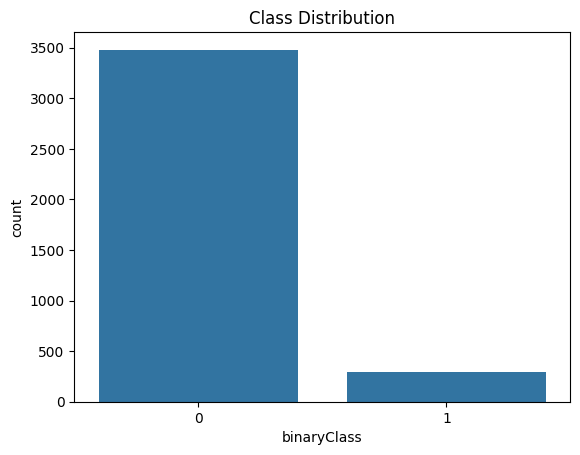

In [18]:
sns.countplot(x =target,data=df)
plt.title("Class Distribution")
plt.show()

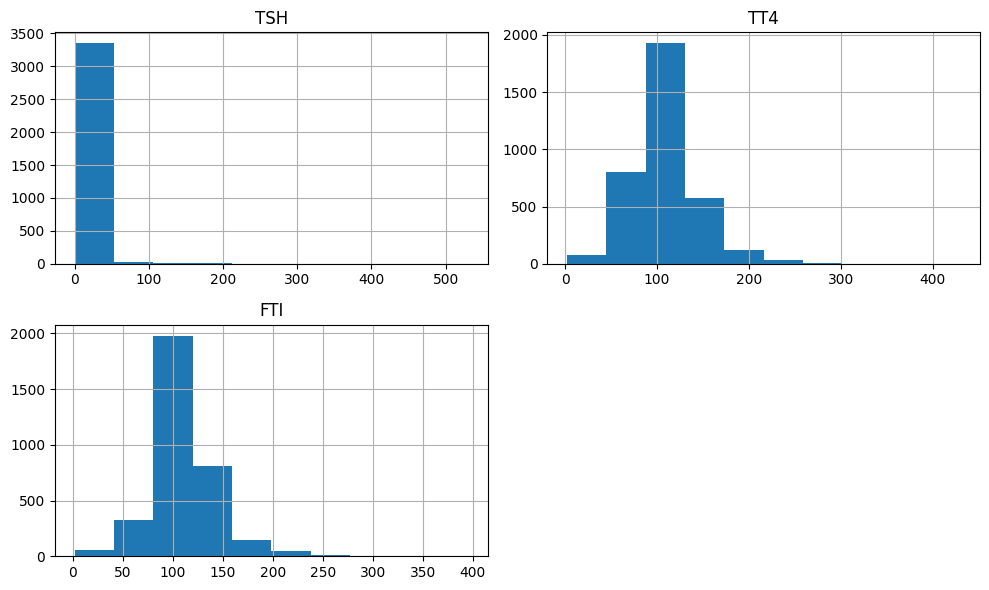

In [20]:
# Hormone Distribution
df[features].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

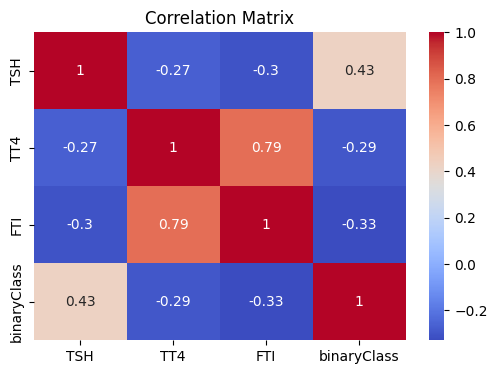

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr() , annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

From EDA we can see that there is a huge class difference so we have to perform SMOTE

In [22]:
X = df[features]
y = df[target]

In [23]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Preprocessing

In [25]:
# Median Imputation + Scaling

numeric_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num" , numeric_transformer , features)
    ]
)

In [27]:
base_models = [
    ("lr" , LogisticRegression(max_iter=1000,class_weight="balanced")),
    ("rf" , RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    )),
    ("gb" , GradientBoostingClassifier(
        n_estimators=300,
        random_state=42
    ))
]

meta_model = LogisticRegression()



In [30]:
# Building Stack Classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

In [31]:
# Full Pipeline With SMOTE

pipeline = ImbPipeline(steps=[
    ("preprocessing" , preprocessor),
    ("smote" , SMOTE(random_state=42)),
    ("classifier", stack_model)
])

In [32]:
# Model training
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['TSH', 'TT4', 'FTI'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 StackingClassifier(cv=5,
                                    estimators=[('lr',
                                                 LogisticRegression(class_weight='balanced',
                                                                    max_iter=1000)),
                                                ('rf',
                                                 RandomForestClassifier(class_weight='balanced',
                                                                        n_estimators=300,
                                                                        random_state=42)),
                                                ('gb',
                                                 GradientBoostingClassifier(n_estimators=300,
                                                                            random_state=42))],
                                    final_estimator=LogisticRegression(),
                                    n_jobs=-1))])

Default Evaluation (Threshold = 0.5)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       697
           1       0.81      0.98      0.89        58

    accuracy                           0.98       755
   macro avg       0.91      0.98      0.94       755
weighted avg       0.98      0.98      0.98       755

ROC_AUC :  0.9951763716420126


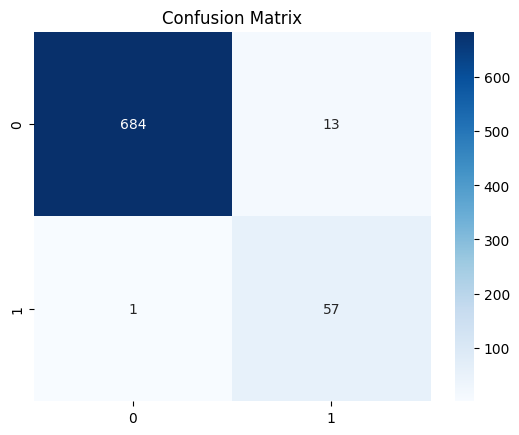

In [34]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test,y_pred))

roc_auc = roc_auc_score(y_test,y_proba)
print("ROC_AUC : ", roc_auc)


sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [35]:
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC:", cv_scores.mean())

Cross-Validation ROC-AUC: 0.9911526246666262


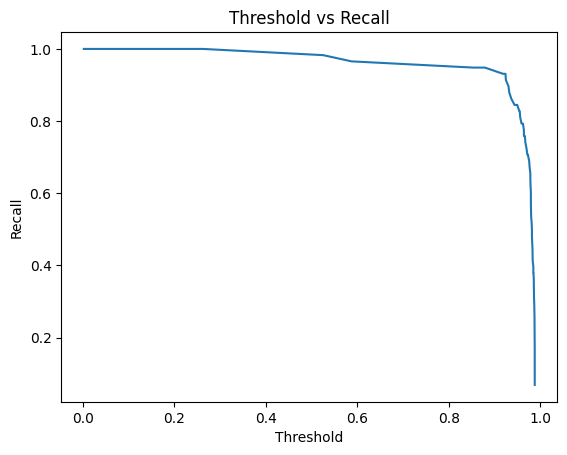

In [38]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, recall[:-1])
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.title("Threshold vs Recall")
plt.show()

In [39]:
custom_threshold = 0.35

y_pred_custom = (y_proba >= custom_threshold).astype(int)

print("Custom Threshold Results:")
print(classification_report(y_test, y_pred_custom))

Custom Threshold Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       697
           1       0.81      0.98      0.89        58

    accuracy                           0.98       755
   macro avg       0.91      0.98      0.94       755
weighted avg       0.98      0.98      0.98       755



In [40]:
joblib.dump(pipeline, "thyroid_stacked_medical_model.pkl")

['thyroid_stacked_medical_model.pkl']